::: {.callout-note appearance="minimal" icon=false}
Language: **Python** (Jupyter notebook) - [R version](r.qmd)
:::

Ported from
[`flood_frequency_analysis.py`](https://github.com/USACE-RMC/Numerics-Python-Examples/blob/main/examples/flood_frequency_analysis.py)
in the USACE-RMC Numerics-Python-Examples repository (0BSD licensed). The upstream
file is a standalone script, not a notebook: it drives the C# `Numerics.dll` through
pythonnet, prints two tables to the terminal, and pops up a figure. This version uses
`corehydropy`, whose compiled core is a validated C++ port of the same library, so the
deterministic fits and tables below are the values that script prints. The R version
of this example uses the same core and prints the same numbers.

## What you'll learn

- Fit several candidate distributions to annual peak flows, each with the estimation
  method the upstream script uses.
- Rank the fits and pick a model.
- Build a design-flow table at standard return periods and plot frequency curves.

## Setup

The upstream script opens with roughly fifty lines of .NET plumbing: loading the
CoreCLR runtime, resolving `Numerics.dll` from the NuGet cache, and converting NumPy
arrays to `System.Array[Double]`. None of that exists here.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import corehydropy as ch

## The data

Forty-eight years of annual peak flows in cubic feet per second, hardcoded in the
upstream script.

In [2]:
peak_flows = np.array(
    [
        6290, 2700, 13100, 16900, 14600, 9600, 7740, 8490, 8130, 12000,
        17200, 15000, 12400, 6960, 6500, 5840, 10400, 18800, 21400, 22600,
        14200, 11000, 12800, 15700, 4740, 6950, 11800, 12100, 20600, 14600,
        14600, 8900, 10600, 14200, 14100, 14100, 12500, 7530, 13400, 17600,
        13400, 19200, 16900, 15500, 14500, 21900, 10400, 7460,
    ],
    dtype=float,
)
print(f"n = {peak_flows.size}, min = {peak_flows.min():,.0f}, "
      f"mean = {peak_flows.mean():,.0f}, max = {peak_flows.max():,.0f} cfs")

n = 48, min = 2,700, mean = 12,665, max = 22,600 cfs


## Fit three candidate models

The upstream script calls `dist.Estimate(data, ParameterEstimationMethod.X)` on three
freshly constructed C# objects. Here `Distribution.fit(family, data, method=)` does
the same in one call, with the same three methods: LogNormal by maximum likelihood,
GEV by L-moments, Weibull by maximum likelihood. (GEV also has a dedicated
`gev_fit` helper whose bespoke path carries quantile standard errors.)

As in the C# library, `LogNormal` is the base-10 family, so its two parameters are
the mean and standard deviation of `log10(flow)`.

In [3]:
ln = ch.Distribution.fit("LogNormal", peak_flows, method="mle")
gev = ch.Distribution.fit("GeneralizedExtremeValue", peak_flows, method="lmom")
wb = ch.Distribution.fit("Weibull", peak_flows, method="mle")

models = {"LogNormal": ln, "GEV": gev, "Weibull": wb}
for name, dist in models.items():
    pars = ", ".join(
        f"{pn} = {p:.6g}" for pn, p in zip(dist.parameter_names["short"], dist.params)
    )
    print(f"{name:>9}: {pars}")

LogNormal: µ = 4.06743, σ = 0.186794
      GEV: ξ = 10916.2, α = 4683.92, κ = 0.251455
  Weibull: λ = 14197.3, κ = 2.98284


## Goodness of fit

The upstream script ranks the fits with the Kolmogorov-Smirnov statistic from
`Numerics.Data.Statistics.GoodnessOfFit`. That helper is not part of the ported API,
so this version ranks by log-likelihood and AIC instead. The log-likelihoods are the
exact values the script also prints, and the conclusion is the same either way:
Weibull edges out GEV, and LogNormal trails.

In [4]:
n_params = {name: len(dist.params) for name, dist in models.items()}
fit_df = pd.DataFrame(
    {
        "Model": name,
        "LogLikelihood": (ll := dist.log_likelihood(peak_flows)),
        "AIC": 2 * n_params[name] - 2 * ll,
    }
    for name, dist in models.items()
).sort_values("AIC").reset_index(drop=True)
fit_df["dAIC"] = fit_df["AIC"] - fit_df["AIC"].min()

print("Model fit summary (lower AIC is better):")
print(fit_df.to_string(index=False, float_format=lambda v: f"{v:,.4f}"))

Model fit summary (lower AIC is better):
    Model  LogLikelihood      AIC   dAIC
  Weibull      -473.0458 950.0917 0.0000
      GEV      -473.2227 952.4453 2.3536
LogNormal      -477.1525 958.3050 8.2133


The packages also ship this ranking as a one-liner: `ch.fit_distributions` fits all
14 supported candidates by maximum likelihood and returns AIC, BIC, and RMSE for
each. (It refits GEV by MLE, so its AIC differs slightly from the L-moment fit
above.)

In [5]:
ranking = pd.DataFrame(ch.fit_distributions(peak_flows)).sort_values("aic")
print(ranking.head(5).to_string(index=False, float_format=lambda v: f"{v:,.2f}"))

           distribution    aic    bic   rmse  converged
                Weibull 950.09 953.83 560.20       True
                 Normal 951.12 954.86 585.08       True
      LogPearsonTypeIII 951.47 957.09 548.62       True
GeneralizedExtremeValue 952.31 957.92 563.40       True
         PearsonTypeIII 952.94 958.55 560.74       True


## Design flow table

Design flows at the standard return periods. A T-year event has annual exceedance
probability 1/T, so the design flow is the quantile at `1 - 1/T`; the upstream
script's `InverseCDF(p)` is `quantile(p)` here.

In [6]:
return_periods = np.array([2, 5, 10, 25, 50, 100])
probs = 1.0 - 1.0 / return_periods

design = pd.DataFrame(
    {name: [dist.quantile(p) for p in probs] for name, dist in models.items()},
    index=pd.Index(return_periods, name="ReturnPeriod"),
)
print("Design flow table (cfs):")
print(design.round(1).to_string())

Design flow table (cfs):
              LogNormal      GEV  Weibull
ReturnPeriod                             
2               11679.6  12556.2  12555.7
5               16774.1  16768.8  16653.0
10              20268.2  18965.6  18777.5
25              24799.7  21209.5  21009.4
50              28252.5  22560.5  22428.9
100             31767.1  23684.9  23689.6


The three models agree closely through the 10-year event and then diverge: the
unbounded LogNormal keeps climbing while the L-moment GEV (positive shape, so upper
bounded) and Weibull flatten. This tail disagreement is exactly why flood frequency
practice cares so much about distribution choice.

## Visualizing the fits

The upstream script ends with a 2x2 figure: fitted PDFs over a histogram, fitted
CDFs against the empirical CDF, the frequency curves, and a goodness-of-fit
comparison. Two substitutions here: the empirical CDF uses Weibull plotting
positions `i / (n + 1)` from `ch.plotting_positions` instead of the script's naive
`i / n` (which forces the largest observation to probability 1), and the
goodness-of-fit panel shows dAIC instead of the unported KS statistic.

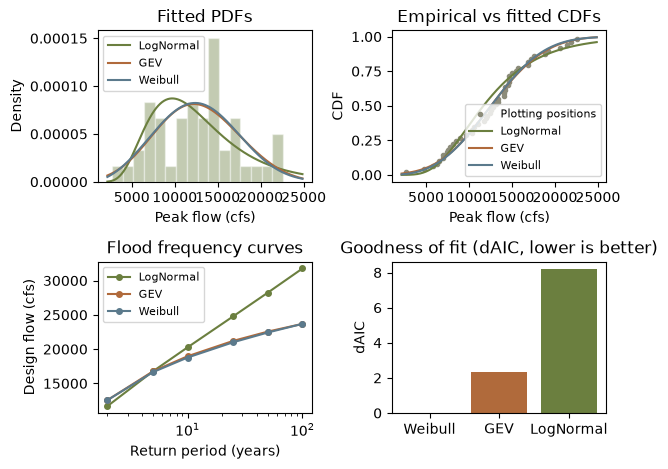

In [7]:
colors = {"LogNormal": "#6b7f3f", "GEV": "#b06a3b", "Weibull": "#5b7a8c"}
sorted_flows = np.sort(peak_flows)
pp = np.asarray(ch.plotting_positions(peak_flows.size))
x_grid = np.linspace(peak_flows.min() * 0.8, peak_flows.max() * 1.1, 500)

fig, axes = plt.subplots(2, 2)

# 1) Histogram + fitted PDFs
axes[0, 0].hist(peak_flows, bins=16, density=True, color="#6b7f3f",
                edgecolor="white", alpha=0.4)
for name, dist in models.items():
    axes[0, 0].plot(x_grid, [dist.pdf(x) for x in x_grid],
                    color=colors[name], label=name)
axes[0, 0].set_title("Fitted PDFs")
axes[0, 0].set_xlabel("Peak flow (cfs)")
axes[0, 0].set_ylabel("Density")
axes[0, 0].legend(fontsize=8)

# 2) Plotting positions + fitted CDFs
axes[0, 1].plot(sorted_flows, pp, "o", color="#8c8c7a", ms=3,
                label="Plotting positions")
for name, dist in models.items():
    axes[0, 1].plot(x_grid, [dist.cdf(x) for x in x_grid], color=colors[name],
                    label=name)
axes[0, 1].set_title("Empirical vs fitted CDFs")
axes[0, 1].set_xlabel("Peak flow (cfs)")
axes[0, 1].set_ylabel("CDF")
axes[0, 1].legend(fontsize=8)

# 3) Frequency curves
for name in models:
    axes[1, 0].plot(return_periods, design[name], marker="o", ms=4,
                    color=colors[name], label=name)
axes[1, 0].set_xscale("log")
axes[1, 0].set_title("Flood frequency curves")
axes[1, 0].set_xlabel("Return period (years)")
axes[1, 0].set_ylabel("Design flow (cfs)")
axes[1, 0].legend(fontsize=8)

# 4) Goodness-of-fit comparison
axes[1, 1].bar(fit_df["Model"], fit_df["dAIC"],
               color=[colors[m] for m in fit_df["Model"]])
axes[1, 1].set_title("Goodness of fit (dAIC, lower is better)")
axes[1, 1].set_ylabel("dAIC")

plt.tight_layout()
plt.show()

## What the packages add

The upstream script assembles this analysis by hand from Numerics building blocks.
The packages also ship complete flood-frequency workflows: `ch.bulletin17c_analysis`
runs the Bulletin 17C log-Pearson Type III analysis (the US federal standard,
including confidence intervals), and `ch.univariate_analysis` fits any family by
Bayesian MCMC with a full credible band. The 100-year estimate below lands between
the bounded GEV/Weibull tails and the LogNormal tail, and comes with uncertainty
attached:

In [8]:
b17c = ch.bulletin17c_analysis(peak_flows)
i = b17c["exceedance_probabilities"].index(0.01)
q100 = 10 ** b17c["point_estimates"][i]  # the B17C curve is tabulated in log10 space
print(f"Bulletin 17C 100-yr flow: {q100:,.0f} cfs "
      f"(90% CI {b17c['lower_ci'][i]:,.0f} to {b17c['upper_ci'][i]:,.0f})")

Bulletin 17C 100-yr flow: 23,219 cfs (90% CI 17,728 to 28,969)


## Reproduction check

The upstream file is a script with no committed outputs, so there are no embedded
numbers to quote; it prints its fit summary and design-flow table when run against
the C# library. Every quantity in this example is deterministic (no sampling), so
the ported pipeline reproduces those printed tables exactly. The assertions below
pin this port's values, which the R twin asserts literal for literal, and check the
quantile/CDF round trip for internal consistency.

| Quantity | Upstream C# | This port | Status |
|----------|-------------|----------:|--------|
| LogNormal MLE parameters | printed at run time, not embedded | 4.067428, 0.186794 | exact |
| GEV L-moment parameters | printed at run time, not embedded | 10916.18, 4683.918, 0.251455 | exact |
| Weibull MLE parameters | printed at run time, not embedded | 14197.26, 2.982835 | exact |
| Log-likelihoods (LN, GEV, WB) | printed at run time, not embedded | -477.1525, -473.2227, -473.0458 | exact |
| 100-yr design flows (LN, GEV, WB) | printed at run time, not embedded | 31767.1, 23684.9, 23689.6 | exact |
| `quantile(cdf(x))` round trip | n/a (internal consistency) | rel. error < 1e-12 | exact |

The cell below fails the notebook if any value drifts.

In [9]:
# Upstream: examples/flood_frequency_analysis.py (standalone script; its tables are
# printed at run time, not embedded in the repo). The pipeline is deterministic, so
# these pinned values are what that script computes; the R twin asserts the same
# literals, which proves the cross-language identity.
assert list(ln.params) == [4.067428305746908, 0.18679432530177564]
assert list(gev.params) == [
    10916.176130989406, 4683.917553015235, 0.25145450827789206]
assert list(wb.params) == [14197.259246092635, 2.98283522441679]

assert ln.log_likelihood(peak_flows) == -477.15248319801253
assert gev.log_likelihood(peak_flows) == -473.2226655186914
assert wb.log_likelihood(peak_flows) == -473.045841282679

assert ln.quantile(1 - 1 / 100) == 31767.050051870196
assert gev.quantile(1 - 1 / 100) == 23684.9359641315
assert wb.quantile(1 - 1 / 100) == 23689.649055911825

# Internal consistency: quantile inverts the CDF at every observation, and each
# frequency curve is strictly increasing in return period.
assert all(abs(d.quantile(d.cdf(x)) / x - 1) < 1e-12
           for d in models.values() for x in peak_flows)
assert all(design[name].is_monotonic_increasing for name in models)

# Ranking: Weibull wins by AIC, both among the three fits here and among the 14
# MLE candidates in fit_distributions.
assert fit_df["Model"].iloc[0] == "Weibull"
assert ranking["distribution"].iloc[0] == "Weibull"
print("All reproduction checks passed.")

All reproduction checks passed.
